In [23]:
import pandas as pd

events = pd.read_csv("events_cleaned.csv")

weights = {
    "Views": 1,
    "addtocart": 3,
    "transactions": 5,
}

events["interaction_score"] = events["event"].map(weights)
events.head()

,timestamp,visitorid,event,itemid,transactionid,interaction_score
0,1433221332117,257597,view,355908,NaN,NaN
1,1433224214164,992329,view,248676,NaN,NaN
2,1433221999827,111016,view,318965,NaN,NaN
3,1433221955914,483717,view,253185,NaN,NaN
4,1433221337106,951259,view,367447,NaN,NaN


In [24]:
user_features = events.groupby("visitorid").agg({
    "itemid": "count",
    "interaction_score":"sum"})

user_features.columns = ["total_interactions","total_score"]
user_features.head()

,total_interactions,total_score
visitorid,,
0,3,0.0
1,1,0.0
2,8,0.0
3,1,0.0
4,1,0.0


In [25]:
user_behavior = events.pivot_table(
    index="visitorid",
    columns="event",
    values="itemid",
    aggfunc="count",
    fill_value=0
)

user_behavior.head()

event,addtocart,transaction,view
visitorid,,,
0,0,0,3
1,0,0,1
2,0,0,8
3,0,0,1
4,0,0,1


In [26]:
user_behavior["cart_rate"] = (user_behavior["addtocart"] / user_behavior["view"])

user_behavior["purchase_rate"] = (user_behavior["transaction"] / user_behavior["view"])
user_behavior.fillna(0, inplace=True)
user_behavior.head()

event,addtocart,transaction,view,cart_rate,purchase_rate
visitorid,,,,,
0,0,0,3,0.0,0.0
1,0,0,1,0.0,0.0
2,0,0,8,0.0,0.0
3,0,0,1,0.0,0.0
4,0,0,1,0.0,0.0


In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = user_behavior[["view","addtocart","transaction","cart_rate","purchase_rate"]]



In [28]:
features.isnull().sum()

event
view             0
addtocart        0
transaction      0
cart_rate        0
purchase_rate    0
dtype: int64

In [29]:
import numpy as np
np.isinf(features).sum()

event
view                0
addtocart           0
transaction         0
cart_rate        3321
purchase_rate     428
dtype: int64

In [30]:
features.describe()

c:\Users\varun\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\varun\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


event,view,addtocart,transaction,cart_rate,purchase_rate
count,1.407580e+06,1.407580e+06,1.407580e+06,1407580.0,1407580.0
mean,1.892765e+00,4.899615e-02,1.595433e-02,inf,inf
std,1.099361e+01,1.163089e+00,8.260909e-01,NaN,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
25%,1.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
50%,1.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
75%,2.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
max,6.479000e+03,7.190000e+02,5.590000e+02,inf,inf


In [31]:
import numpy as np

features.isnull().sum()
features.describe()

features = features.replace([np.inf , -np.inf],0)
features = features.fillna(0)

c:\Users\varun\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\varun\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [32]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [33]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

user_behavior["cluster"] = kmeans.fit_predict(scaled_features)
user_behavior["cluster"].value_counts()

cluster
0    1402499
2       5029
3         49
1          3
Name: count, dtype: int64

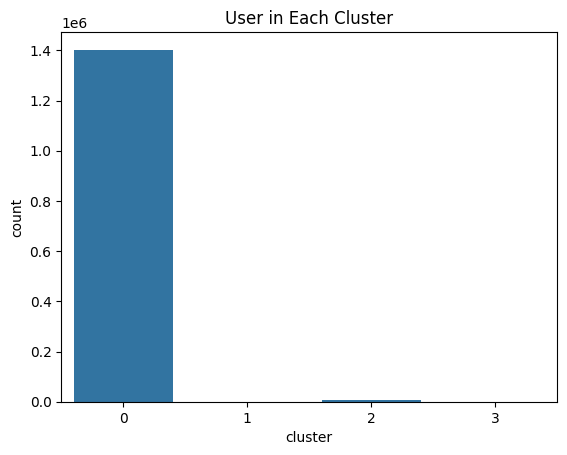

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x= "cluster", data=user_behavior)
plt.title("User in Each Cluster")
plt.show()

In [35]:
user_behavior.groupby("cluster")[["view","addtocart","transaction","cart_rate","purchase_rate"]].mean()

event,view,addtocart,transaction,cart_rate,purchase_rate
cluster,,,,,
0,1.839681,0.036601,0.007089,inf,inf
1,4135.333333,503.000000,398.000000,0.129216,0.105565
2,3.973553,2.204812,1.560549,inf,0.747327
3,1054.653061,102.775510,70.857143,0.174947,0.084059


In [36]:
sample_events = events.sample(100000,random_state=42)

In [37]:
sample_events = events.sample(frac=0.2,random_state=42)

In [38]:
top_users = sample_events["visitorid"].value_counts().head(600).index
top_items = sample_events["itemid"].value_counts().head(300).index

filtered_events = sample_events[
    sample_events["visitorid"].isin(top_users) &
    sample_events["itemid"].isin(top_items)
]


In [39]:
filtered_events["visitorid"].nunique()
filtered_events["itemid"].nunique()

245

In [40]:
user_item_matrix = filtered_events.pivot_table(
    index ="visitorid",
    columns = "itemid",
    values = "interaction_score",
    aggfunc = "sum",
    fill_value =0
)

print(user_item_matrix.shape)

(329, 245)


In [41]:
user_behavior["high_value_user"] = (
    user_behavior["purchase_rate"] >
    user_behavior["purchase_rate"].median()   
).astype(int)

user_behavior["high_value_user"].value_counts()

high_value_user
0    1395861
1      11719
Name: count, dtype: int64

In [42]:
x = user_behavior[["view","addtocart"]]

y = user_behavior["high_value_user"]

In [43]:
import numpy as np

x.isin([np.inf, -np.inf]).sum()

event
view         0
addtocart    0
dtype: int64

In [44]:
import numpy as np

x = x.replace([np.inf, -np.inf],np.nan)

x= x.fillna(0)

In [45]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train ,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(x_train.shape)
print(x_test.shape)

(1126064, 2)
(281516, 2)


In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)

x_train_smote , y_train_smote = smote.fit_resample(x_train,y_train)

x_train_smote.shape , y_train_smote.shape

((2233378, 2), (2233378,))

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(
    random_state=42)

dt_model.fit(x_train_smote,y_train_smote)

y_pred = dt_model.predict(x_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    279172
           1       0.25      0.90      0.40      2344

    accuracy                           0.98    281516
   macro avg       0.63      0.94      0.69    281516
weighted avg       0.99      0.98      0.98    281516



In [48]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.9770847838133534


In [49]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)

x_train_smote , y_train_smote = smote.fit_resample(x_train,y_train)

x_train_smote.shape , y_train_smote.shape

((2233378, 2), (2233378,))

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
y_pred_rf = rf_model.predict(x_test)

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    279172
           1       0.25      0.91      0.40      2344

    accuracy                           0.98    281516
   macro avg       0.63      0.94      0.69    281516
weighted avg       0.99      0.98      0.98    281516



In [54]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": x.columns,
    "importance": rf_model.feature_importances_
})

importance.sort_values(
    by = "importance",
    ascending=False
)

,Feature,importance
1,addtocart,0.790133
0,view,0.209867


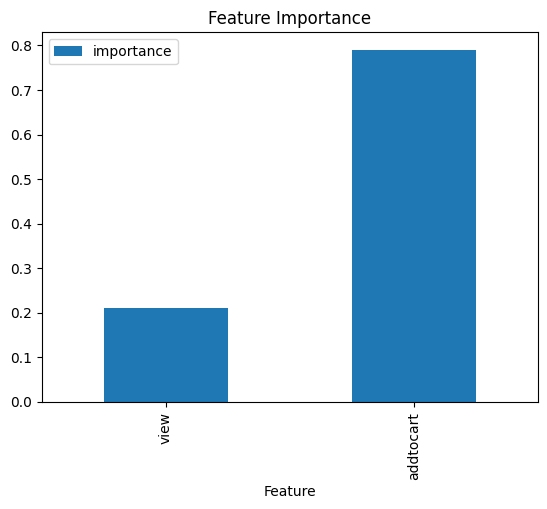

In [57]:
import matplotlib.pyplot as plt

importance.sort_values(
    by = "importance",
    ascending=True
).plot(
    x = "Feature",
    y = "importance",
    kind = "bar"
)

plt.title("Feature Importance")
plt.savefig("random_forest_feature_importance.png")
plt.show()

In [62]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state = 42,
    eval_metric = "logloss"
)

xgb_model.fit(x_train_smote,y_train_smote)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [63]:
y_pred_xgb = xgb_model.predict(x_test)

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    279172
           1       0.25      0.91      0.40      2344

    accuracy                           0.98    281516
   macro avg       0.63      0.95      0.69    281516
weighted avg       0.99      0.98      0.98    281516



In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_xgb)
print(cm)

[[272909   6263]
 [   201   2143]]


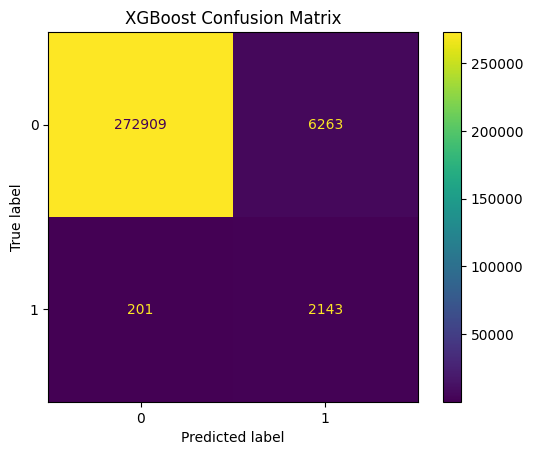

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)

plt.title("XGBoost Confusion Matrix")
plt.savefig("xgboost_confusion_matrix.png")
plt.show()